# Projet Méthodes Stochastiques — notebook

Code et simulations du projet proie-prédateur avec virus. Le contexte, la démarche
et la discussion des résultats sont dans le rapport ; ce notebook se concentre sur
le code qui charge les données, estime les paramètres et régénère les figures.

## Question 1 — modèle du virus (`virus4.csv`)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as scs

# Le fichier n'a pas d'en-tete : on nomme les colonnes a la main.
data = pd.read_csv("virus4.csv", header=None, names=["V", "P"])
V = data["V"].values
P = data["P"].values
N = len(data)
N

2000

### Estimation du pas de temps `dt`

In [2]:
# L'equation des predateurs est deterministe (dP = P(-1+V)dt) : on inverse le
# schema d'Euler pour estimer dt point par point, puis on moyenne. On ecarte les
# points ou V est proche de 1, qui annulent le denominateur.
dP = np.diff(P)
denom = P[:-1] * (-1 + V[:-1])
masque = np.abs(V[:-1] - 1) > 0.05

dt = np.mean(dP[masque] / denom[masque])
tau = N * dt
print(f"dt ~ {dt:.4f}, tau ~ {tau:.1f}")

dt ~ 0.0150, tau ~ 30.0


### Populations observées

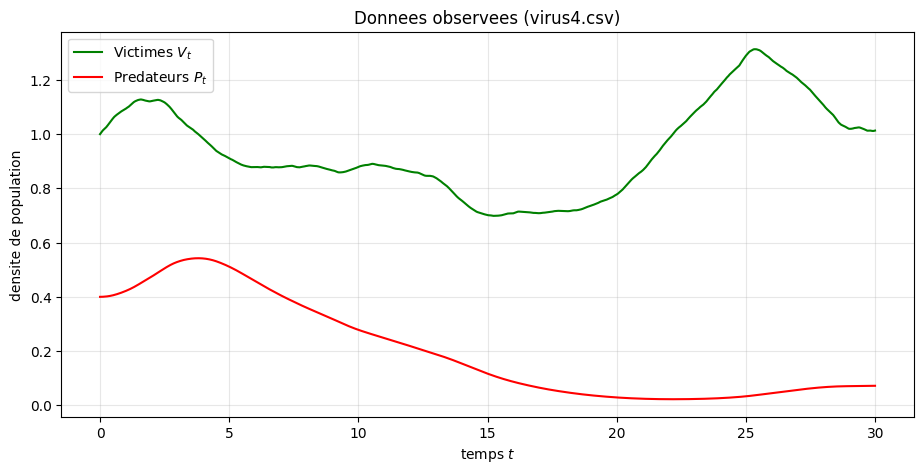

In [3]:
t = np.arange(N) * dt

plt.figure(figsize=(11, 5))
plt.plot(t, V, color="green", label="Victimes $V_t$")
plt.plot(t, P, color="red", label="Predateurs $P_t$")
plt.xlabel("temps $t$")
plt.ylabel("densite de population")
plt.title("Donnees observees (virus4.csv)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("figures/virus4_series.png", dpi=150, bbox_inches="tight")
plt.show()

### Comparaison avec le modèle de Lotka-Volterra classique (sans $X_t$)

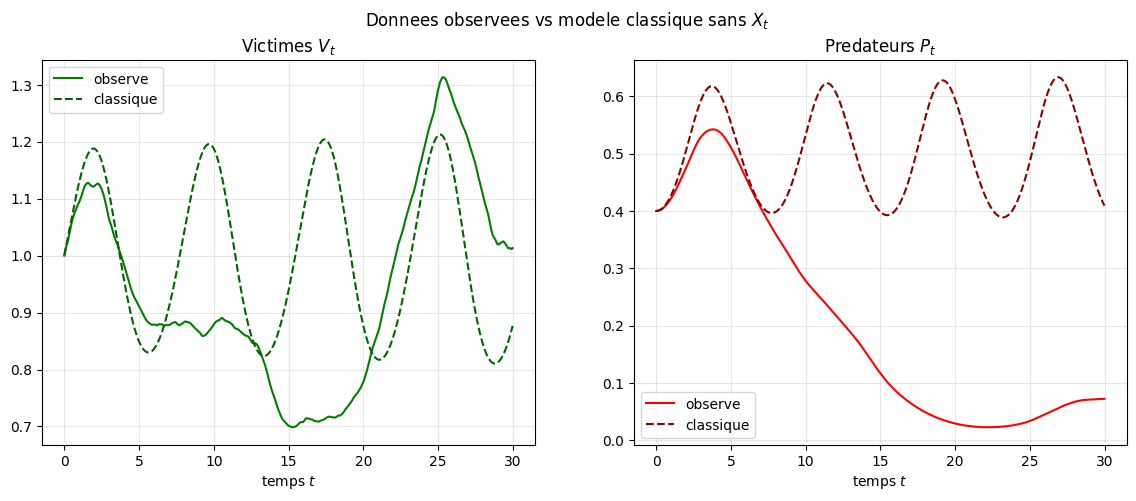

In [4]:
a, b, c, d = 2/3, 4/3, 1, 1

Vc = np.zeros(N)
Pc = np.zeros(N)
Vc[0], Pc[0] = V[0], P[0]   # memes conditions initiales que les donnees

# Euler explicite sur la meme grille de temps que les observations.
for i in range(N - 1):
    Vc[i+1] = Vc[i] + Vc[i] * (a - b * Pc[i]) * dt
    Pc[i+1] = Pc[i] + Pc[i] * (-c + d * Vc[i]) * dt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Donnees observees vs modele classique sans $X_t$")

axes[0].plot(t, V, color="green", label="observe")
axes[0].plot(t, Vc, color="darkgreen", linestyle="--", label="classique")
axes[0].set_title("Victimes $V_t$")
axes[0].set_xlabel("temps $t$")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(t, P, color="red", label="observe")
axes[1].plot(t, Pc, color="darkred", linestyle="--", label="classique")
axes[1].set_title("Predateurs $P_t$")
axes[1].set_xlabel("temps $t$")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.savefig("figures/virus4_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()